In [1]:
from Apriori import apriori

In [2]:
#Connect to Database
from pymongo import MongoClient
from bson import ObjectId
client = MongoClient('mongodb://localhost:27017/')  
print('Connected to MongoDB')
db = client['nlp-based-sentiment-analysis']
markets = db['markets']
prices = db['prices']
tweets = db['tweets']
economic_indicators = db['economicindicators']
keywords = db['keywords']

Connected to MongoDB


In [3]:
#Visualize data
import pandas as pd
import matplotlib.pyplot as plt

def show_table(data, fields):
    df = pd.DataFrame(data=data)
    df = df[fields]
    df.sort_values(by=fields[0], inplace=True)
    return df

#Markets
show_table(list(markets.find({})), ["name", "_id"])

,name,_id
1,Amazon,6511914e0ef18f573bbaaef7
2,Apple,651191fe78ae8da19ab7c36c
0,Bitcoin,651190e1ecfac48ef56a09a4
3,Google,651192563a3effb2a61c3e3c
4,Microsoft,651192804ab1a96068cf401b
5,Tesla,6511928ffcd8828db8c32abc


In [4]:
#Amazon Data
show_table(list(prices.find({"market": ObjectId("6511914e0ef18f573bbaaef7")})), ["date", "close", "volume"])

,date,close,volume
0,2013-07-08T00:00:00.000Z,14.529500,60934000
1,2013-07-09T00:00:00.000Z,14.576500,55512000
2,2013-07-10T00:00:00.000Z,14.616500,36204000
3,2013-07-11T00:00:00.000Z,14.983000,80146000
4,2013-07-12T00:00:00.000Z,15.377500,90786000
...,...,...,...
2512,2023-06-29T00:00:00.000Z,127.900002,40761000
2513,2023-06-30T00:00:00.000Z,130.360001,54310500
2514,2023-07-03T00:00:00.000Z,130.220001,28264800
2515,2023-07-05T00:00:00.000Z,130.380005,35895400


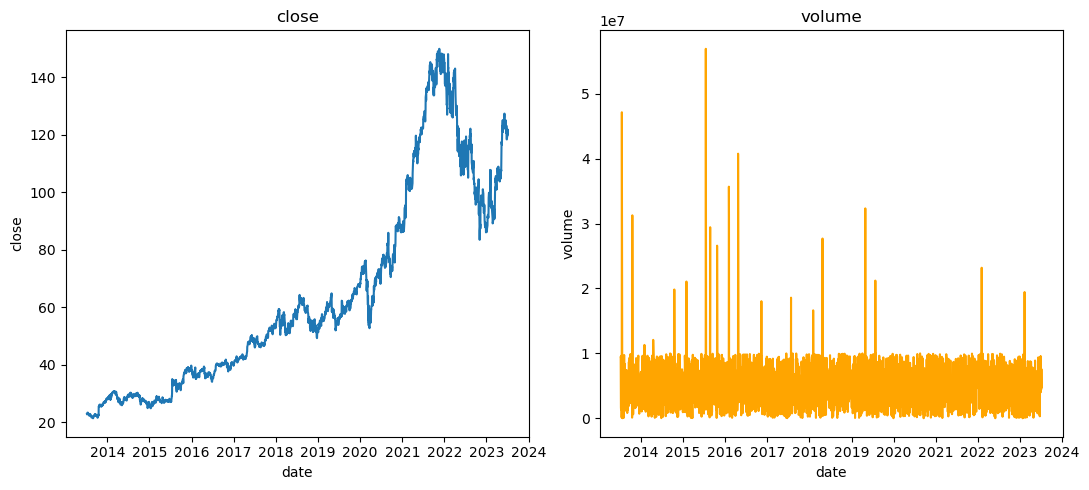

In [5]:
def print_plots(dataframe_a, dataframe_b, field_a, field_b, custom_a_name='', custom_b_name=''):
    dataframe_a['date'] = pd.to_datetime(dataframe_a['date'])
    dataframe_b['date'] = pd.to_datetime(dataframe_b['date'])
    plt.figure(figsize=(11,5))
    plt.subplot(1,2,1)
    plt.plot(dataframe_a['date'], dataframe_a[field_a])
    plt.title(custom_a_name if custom_a_name else field_a)
    plt.xlabel("date")
    plt.ylabel(custom_a_name if custom_a_name else field_a)
    plt.subplot(1,2,2)
    plt.plot(dataframe_b['date'], dataframe_b[field_b], color="orange")
    plt.title(custom_b_name if custom_b_name else field_b)
    plt.xlabel("date")
    plt.ylabel(custom_b_name if custom_b_name else field_b)
    plt.tight_layout()
    plt.show()

google_df = pd.DataFrame(data=list(prices.find({"market": ObjectId("651192563a3effb2a61c3e3c")})))
#Print Google Market Chart
print_plots(pd.DataFrame(data=google_df), pd.DataFrame(data=google_df), 'close', 'volume')

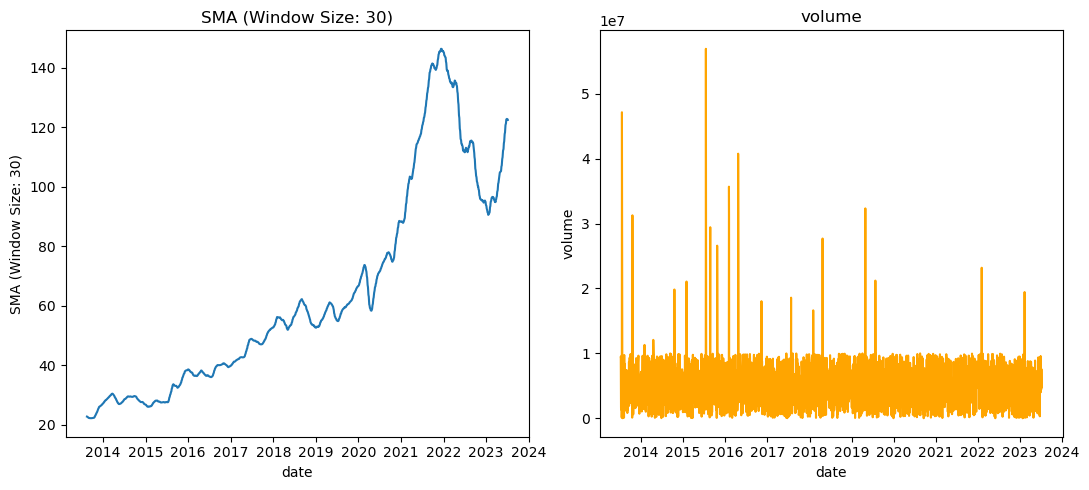

In [6]:
def sma(data, window_size):
    return data.rolling(window=window_size).mean()

#Apply Simple Moving Average to Close Value
google_df["close"] = sma(google_df["close"], window_size=30)
print_plots(pd.DataFrame(data=google_df), pd.DataFrame(data=google_df), 'close', 'volume', custom_a_name="SMA (Window Size: 30)")

In [7]:
show_table(list(set([doc['type'] for doc in economic_indicators.find()])), [0])

,0
6,CPI
8,DurableGoodsOrders
0,FederalFundsRate
5,Inflation
2,NonfarmPayroll
1,RealGDP
3,RealGDPPerCapita
9,RetailSales
4,TreasuryYield
7,UnemploymentRate


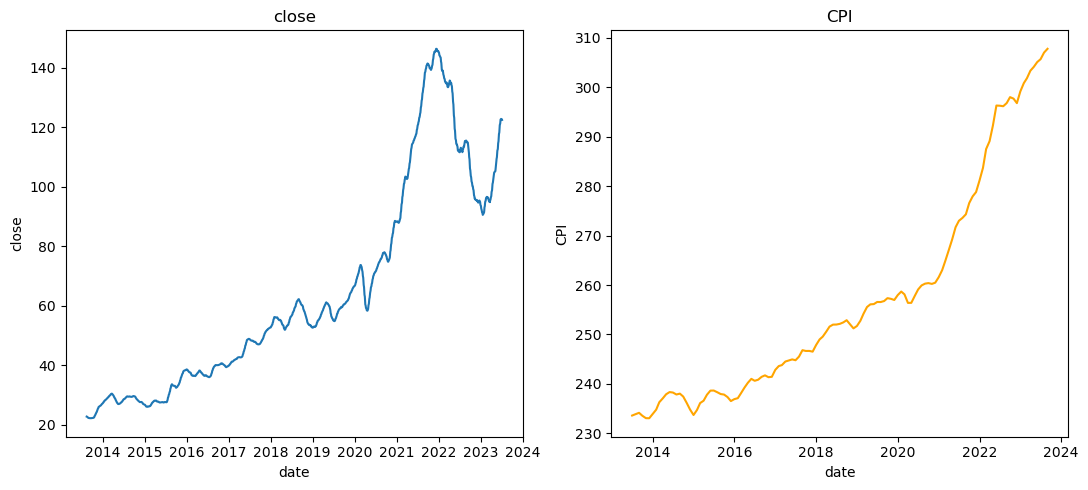

In [8]:
from datetime import datetime
#Show SMA Value next to Technical indicators:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({ "type": "CPI", "date": { "$gte": "2013-07-01" }}))),
    'close', 
    'value', 
    custom_b_name="CPI"
)

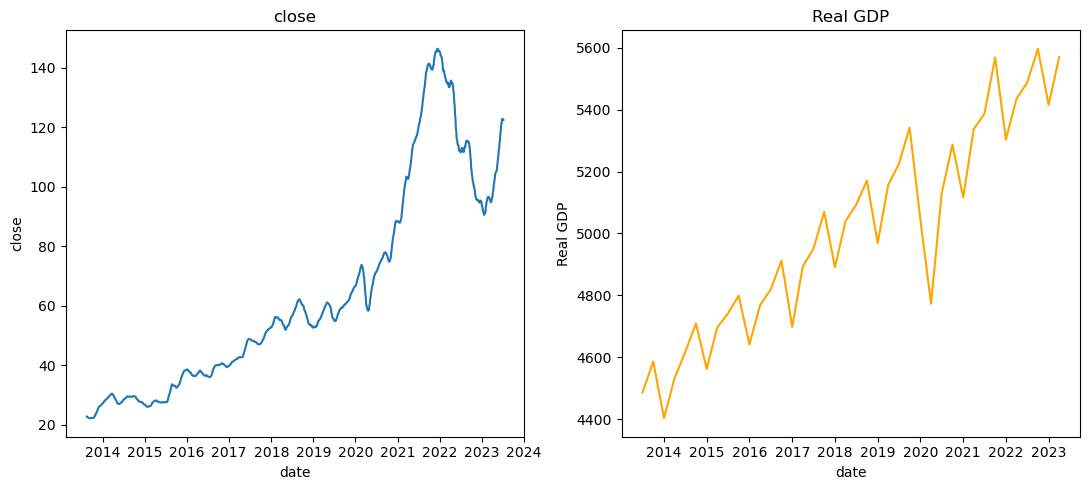

In [9]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "RealGDP", "date": { "$gte": "2013-07-01" }  }))),
    'close',
    'value',
    custom_b_name="Real GDP"
)

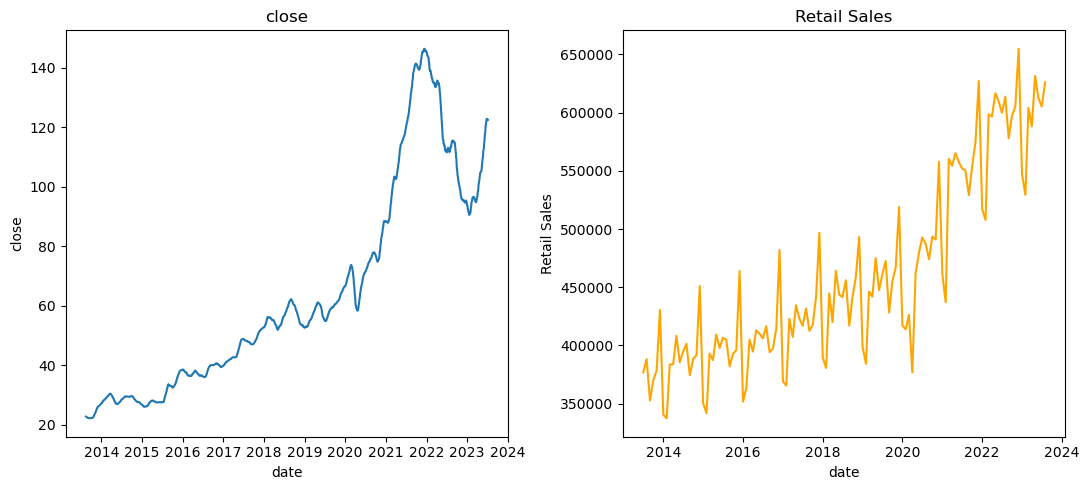

In [10]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "RetailSales", "date": { "$gte": "2013-07-01" } }))), 
    'close',
    'value',
    custom_b_name="Retail Sales"
)

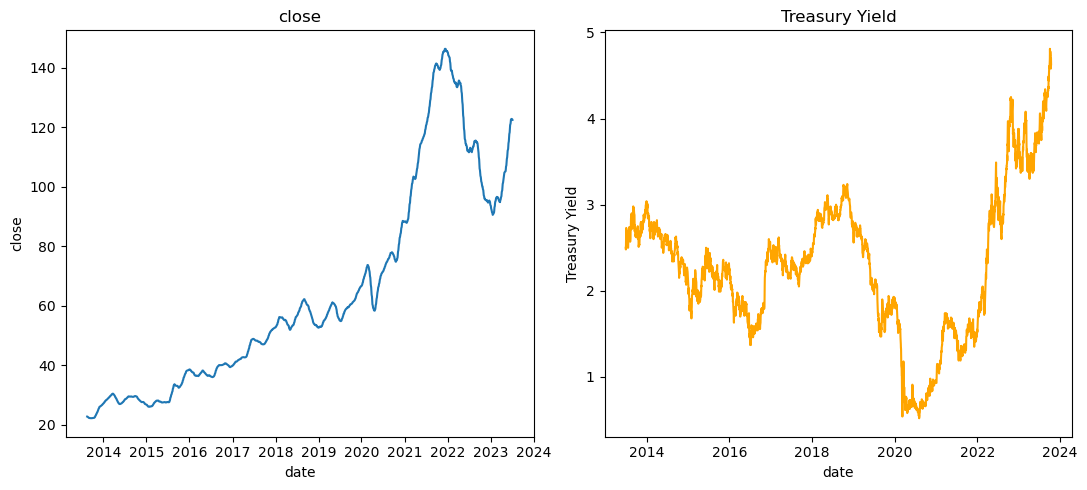

In [11]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "TreasuryYield", "date": { "$gte": "2013-07-01" } }))),
    'close',
    'value',
    custom_b_name="Treasury Yield"
)

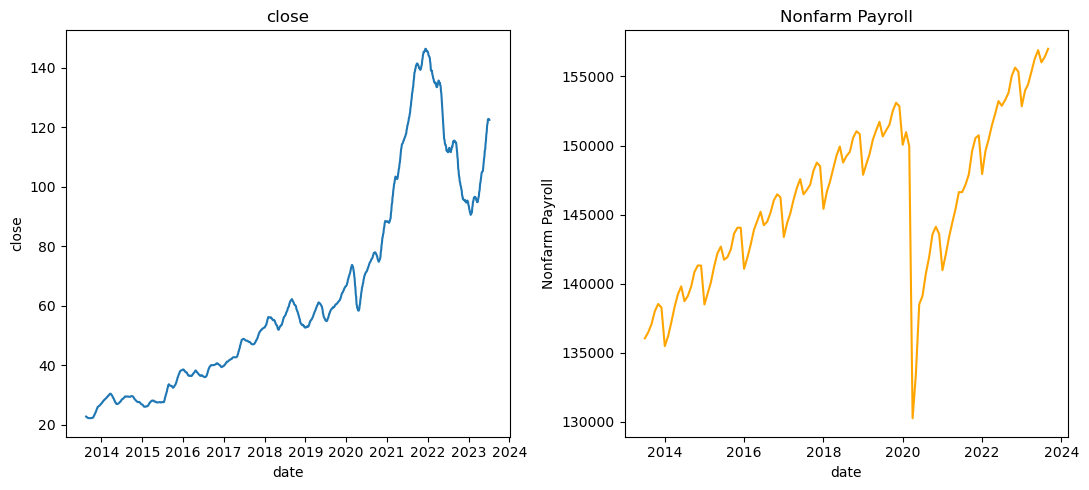

In [12]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "NonfarmPayroll", "date": { "$gte": "2013-07-01" } }))),
    'close',
    'value',
    custom_b_name="Nonfarm Payroll"
)

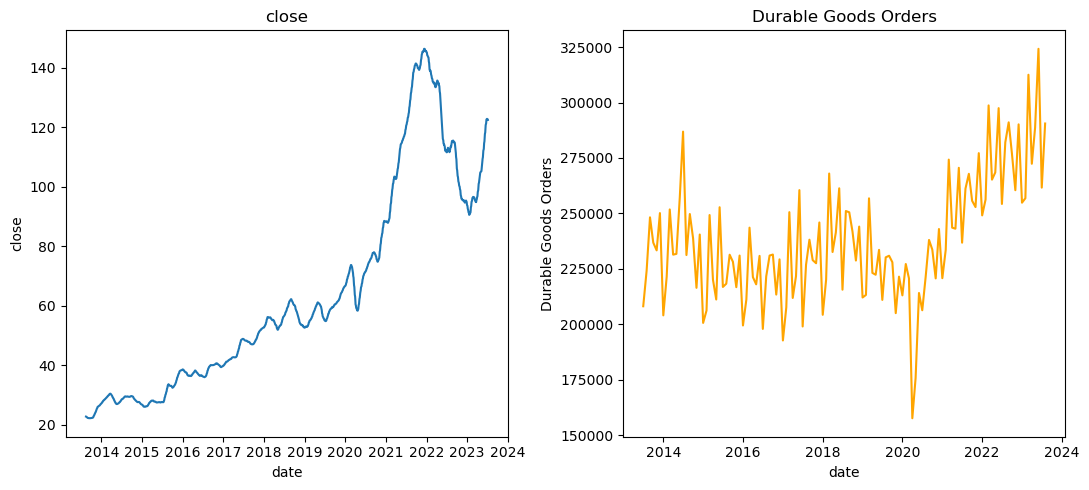

In [13]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "DurableGoodsOrders", "date": { "$gte": "2013-07-01" } }))),
    'close',
    'value',
    custom_b_name="Durable Goods Orders"
)

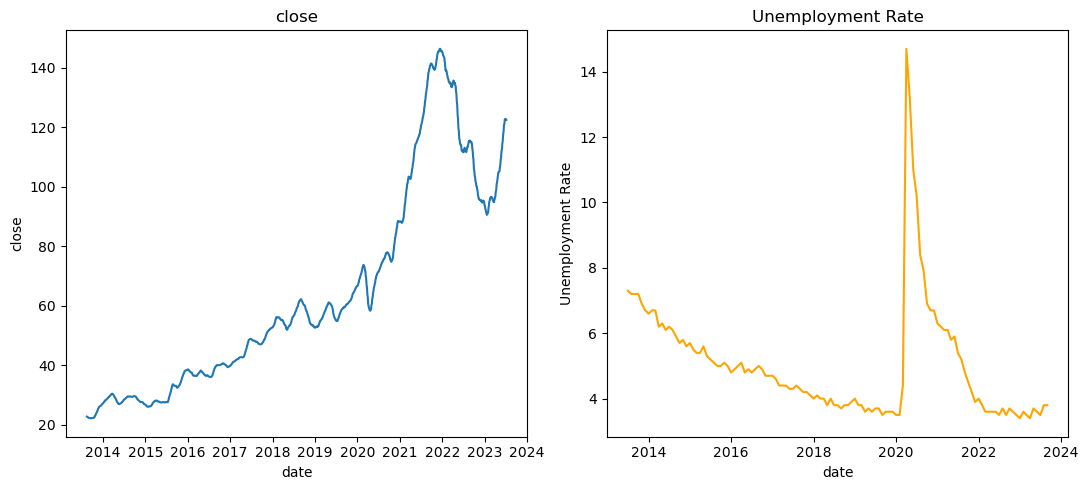

In [14]:
print_plots(
    pd.DataFrame(data=google_df),
    pd.DataFrame(data=list(economic_indicators.find({"type": "UnemploymentRate", "date": { "$gte": "2013-07-01" } }))),
    'close',
    'value',
    custom_b_name="Unemployment Rate"
)

In [15]:
show_table(pd.DataFrame(data=list(keywords.find())), ["name", "_id"])

,name,_id
1,Bitcoin,65118dfb8cc92b1a20969084
0,Investing,65108e38c1df798eb02becb3


In [16]:
tweet_list = tweets.find({"keyword": ObjectId("65108e38c1df798eb02becb3")})

In [17]:
show_table(pd.DataFrame(data=list(tweet_list)), ["date", "content"])

,date,content
491,2015-01-01T21:35:12.000Z,Difference between Following and Capturing Tre...
490,2015-01-01T21:35:13.000Z,Machine Learning vs Systematic Trading http://...
489,2015-01-01T21:35:19.000Z,How a Manager Knew He Wanted to Be a Trader ht...
488,2015-01-01T21:35:44.000Z,Questions Missed During Due Diligence http://t...
487,2015-01-01T21:36:16.000Z,Insights From Seasoned Trend Follower http://t...
...,...,...
1206832,2022-12-31T23:55:32.000Z,#OptionChain - #KOTAKBANK\n#Stock #Bearish\n#P...
1206831,2022-12-31T23:55:32.000Z,Will Your Strategy Outperform? https://t.co/6H...
1206830,2022-12-31T23:57:51.000Z,Happy New Year\nhttps://t.co/UrsDuKgDs1\n#inve...
1206829,2022-12-31T23:58:05.000Z,Wishing everyone a Happy New Year! Let's leave...


In [18]:
import re
def apply_transformations(transformations, text):
    if "REMOVE_USERNAMES" in transformations:
        remove_usernames_pattern = r'@\S+'
        text = re.sub(remove_usernames_pattern, "", text)
    if "REMOVE_URLS" in transformations:
        remove_urls_pattern = r'http\S+'
        text = re.sub(remove_urls_pattern, "", text)
    if "REMOVE_PUNCTUATION_MARKS" in transformations:
        remove_pun_pattern_1 = r"(?<!\d)\.(?!\d)|[^\w\s.']"
        remove_pun_pattern_2 = r"'"
        remove_pun_pattern_3 = r"\s\s+"
        sub1 = re.sub(remove_pun_pattern_1, " ", text)
        sub2 = re.sub(remove_pun_pattern_2, "", sub1)
        text = re.sub(remove_pun_pattern_3, " ", sub2)
    if "TEXT_TO_LOWER" in transformations:
        text = text.lower()
    if "REMOVE_SHORT_WORDS" in transformations:
        remove_short_pattern = r'\b\w{1,2}\b'
        text = re.sub(remove_short_pattern, '', text)
    return text

In [19]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
analyzer = SentimentIntensityAnalyzer()

def sentiment_analyze(text):
    return analyzer.polarity_scores(text)

sentiment_analyze("I love Python!")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\micha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


{'neg': 0.0, 'neu': 0.182, 'pos': 0.818, 'compound': 0.6696}

In [20]:
from sklearn.feature_extraction.text import CountVectorizer
nltk.download('punkt')

def text_vectorizer(text):
    tokenized = nltk.tokenize.word_tokenize(text)
    vectorizer = CountVectorizer()
    return vectorizer.fit_transform(tokenized).toarray()

text = "I would really like to tokenize and vectorize this sentence!" 
text_vectorizer(text)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\micha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=int64)

In [21]:
investing_tweet_list = tweets.find({"keyword": ObjectId("65108e38c1df798eb02becb3")})
transform_types = ["REMOVE_USERNAMES", "REMOVE_URLS", "REMOVE_PUNCTUATION_MARKS", "TEXT_TO_LOWER", "REMOVE_SHORT_WORDS"]
transformed_tweet_list = [{
    "date": obj["date"],
    "content": 
        apply_transformations(transform_types, obj["content"]),
    **sentiment_analyze(apply_transformations(transform_types, obj["content"]))
} for obj in investing_tweet_list]


In [22]:
show_table(pd.DataFrame(data=list(transformed_tweet_list)), ["date", "content", "pos", "neg", "neu", "compound"])

,date,content,pos,neg,neu,compound
491,2015-01-01T21:35:12.000Z,difference between following and capturing tre...,0.000,0.000,1.000,0.0000
490,2015-01-01T21:35:13.000Z,machine learning systematic trading futures t...,0.000,0.000,1.000,0.0000
489,2015-01-01T21:35:19.000Z,how manager knew wanted trader stocks tra...,0.000,0.000,1.000,0.0000
488,2015-01-01T21:35:44.000Z,questions missed during due diligence profit t...,0.180,0.137,0.683,0.1779
487,2015-01-01T21:36:16.000Z,insights from seasoned trend follower stocks t...,0.000,0.000,1.000,0.0000
...,...,...,...,...,...,...
1206832,2022-12-31T23:55:32.000Z,optionchain kotakbank stock bearish pcr .\nma...,0.000,0.000,1.000,0.0000
1206831,2022-12-31T23:55:32.000Z,will your strategy outperform oct 2015 investi...,0.000,0.000,1.000,0.0000
1206830,2022-12-31T23:57:51.000Z,happy new year investing firsttimehome buyers ...,0.236,0.000,0.764,0.5719
1206829,2022-12-31T23:58:05.000Z,wishing everyone happy new year lets leave 20...,0.331,0.077,0.592,0.8625


In [23]:
def merge_and_accumulate(data):
    daily_data = {}
    for entry in data:
        datetime_object = datetime.strptime(entry["date"][:-1], '%Y-%m-%dT%H:%M:%S.%f')
        date_obj = datetime_object.strftime('%Y-%m-%d')
        if date_obj in daily_data:
            daily_data[date_obj]["pos"].append(entry["pos"])
            daily_data[date_obj]["neg"].append(entry["neg"])
            daily_data[date_obj]["neu"].append(entry["neu"])
            daily_data[date_obj]["compound"].append(entry["compound"])
        else:
            daily_data[date_obj] = {
                "pos": [entry["pos"]],
                "neg": [entry["neg"]],
                "neu": [entry["neu"]],
                "compound": [entry["compound"]]
            }
    mapped_array = []
    for date, info in daily_data.items():
        mapped_array.append({
            "date": date,
            "pos_avg": sum(info["pos"]) / len(info["pos"]),
            "neg_avg": sum(info["neg"]) / len(info["neg"]),
            "neu_avg": sum(info["neu"]) / len(info["neu"]),
            "compound_avg": sum(info["compound"]) / len(info["compound"])
        })
    return mapped_array

In [24]:
average_sentiments = list(merge_and_accumulate(transformed_tweet_list))

In [25]:
show_table(pd.DataFrame(data=average_sentiments), ["date", "pos_avg", "neg_avg", "neu_avg", "compound_avg"])

,date,pos_avg,neg_avg,neu_avg,compound_avg
0,2015-01-01,0.190041,0.061222,0.748730,0.261172
1,2015-01-02,0.198655,0.058135,0.743191,0.277338
2,2015-01-03,0.199753,0.061235,0.738984,0.281095
3,2015-01-04,0.204832,0.058584,0.736552,0.289359
4,2015-01-05,0.179689,0.051098,0.769199,0.257767
...,...,...,...,...,...
2552,2022-12-27,0.116012,0.026424,0.857576,0.245916
2553,2022-12-28,0.195740,0.020566,0.783698,0.422400
2554,2022-12-29,0.093424,0.022733,0.883836,0.204483
2555,2022-12-30,0.106208,0.028798,0.864994,0.212447


In [26]:
google_df = pd.DataFrame(data=google_df)
average_sentiments_df = pd.DataFrame(data=average_sentiments)

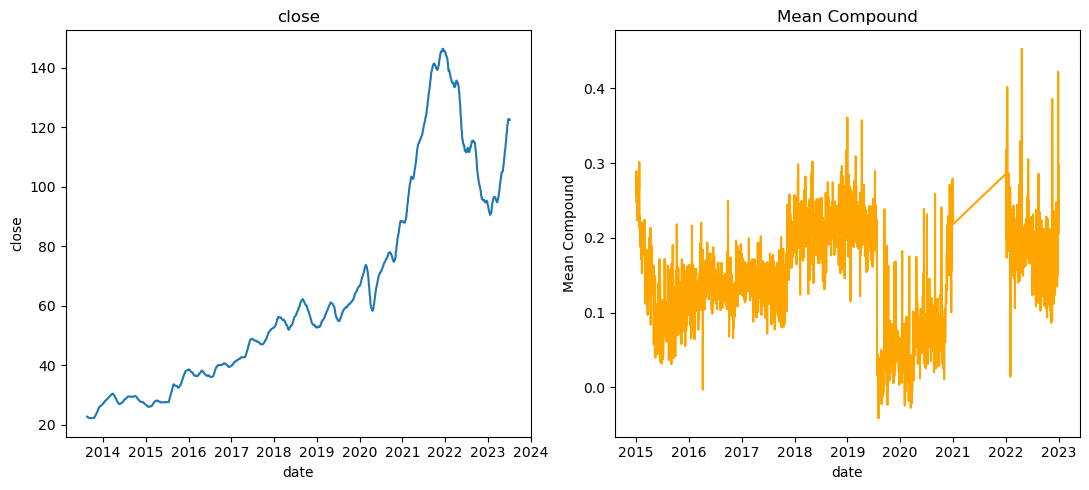

In [27]:
print_plots(
    google_df,
    average_sentiments_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound"
)

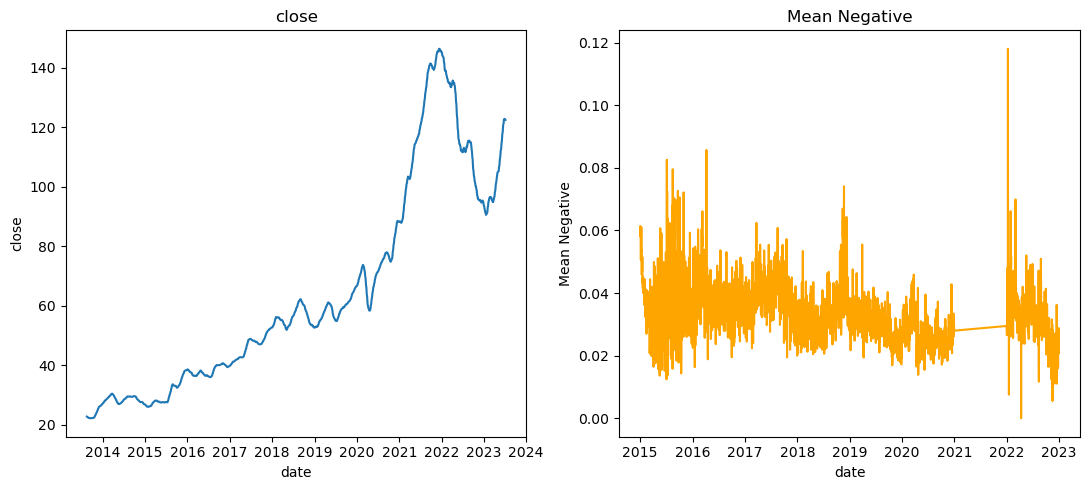

In [28]:
print_plots(
    google_df,
    average_sentiments_df,
    'close',
    'neg_avg',
    custom_b_name="Mean Negative"
)

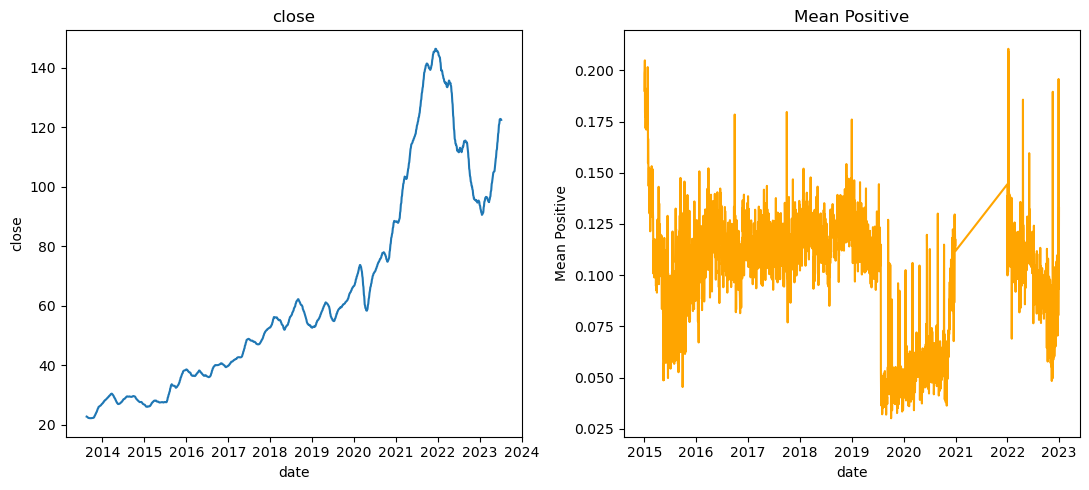

In [29]:
print_plots(
    google_df,
    average_sentiments_df,
    'close',
    'pos_avg',
    custom_b_name="Mean Positive"
)

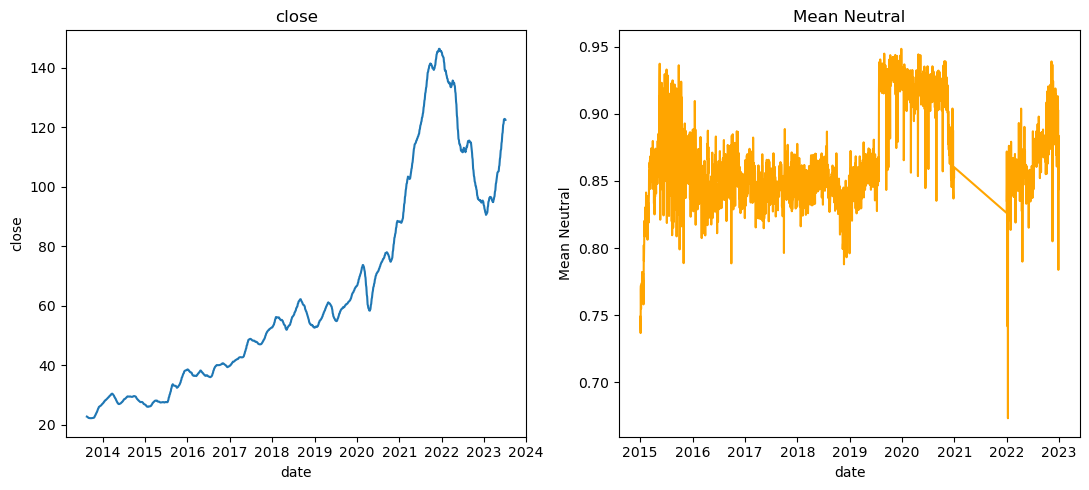

In [30]:
print_plots(
    google_df,
    average_sentiments_df,
    'close',
    'neu_avg',
    custom_b_name="Mean Neutral"
)

In [31]:
import numpy as np

def apply_min_max(data):
    return (data - np.min(data, axis=0)) / (np.max(data, axis=0) - np.min(data, axis=0))
def apply_standarization(data):
    return (data - np.mean(data)) / np.std(data)

In [32]:
average_sentiments_min_max = average_sentiments_df
average_sentiments_min_max["compound_avg"] = apply_min_max(average_sentiments_min_max["compound_avg"])

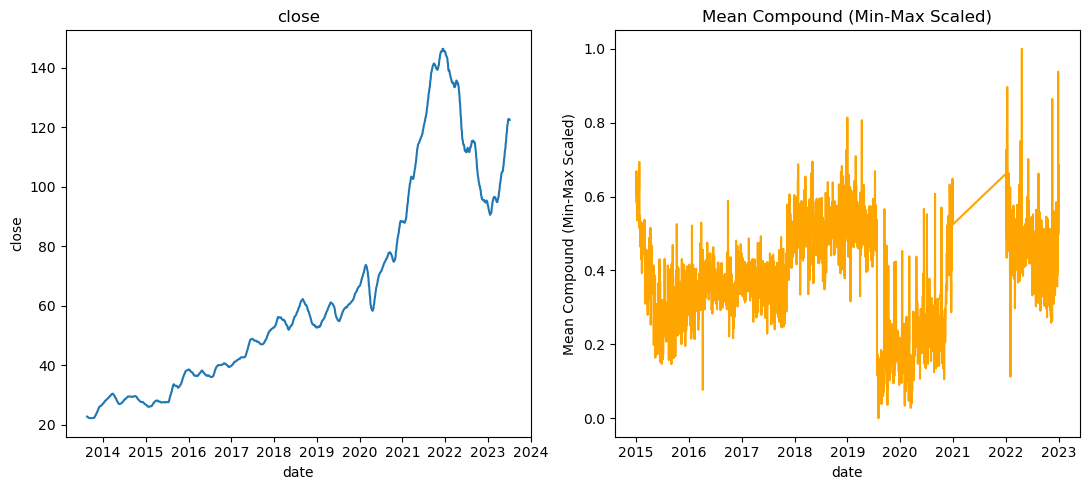

In [33]:
print_plots(
    google_df,
    average_sentiments_min_max,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Min-Max Scaled)"
)

In [34]:
average_sentiments_std = average_sentiments_df
average_sentiments_std["compound_avg"] = apply_standarization(average_sentiments_std["compound_avg"])

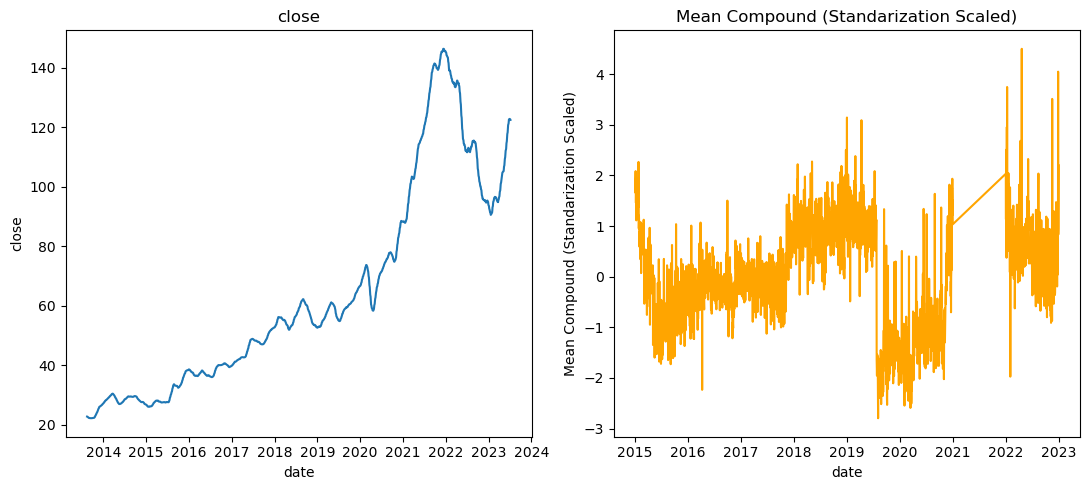

In [35]:
print_plots(
    google_df,
    average_sentiments_std,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Standarization Scaled)"
)

In [36]:
average_sentiments_minmax_sma = average_sentiments_df
average_sentiments_minmax_sma["compound_avg"] = sma(apply_min_max(average_sentiments_minmax_sma["compound_avg"]), 30)

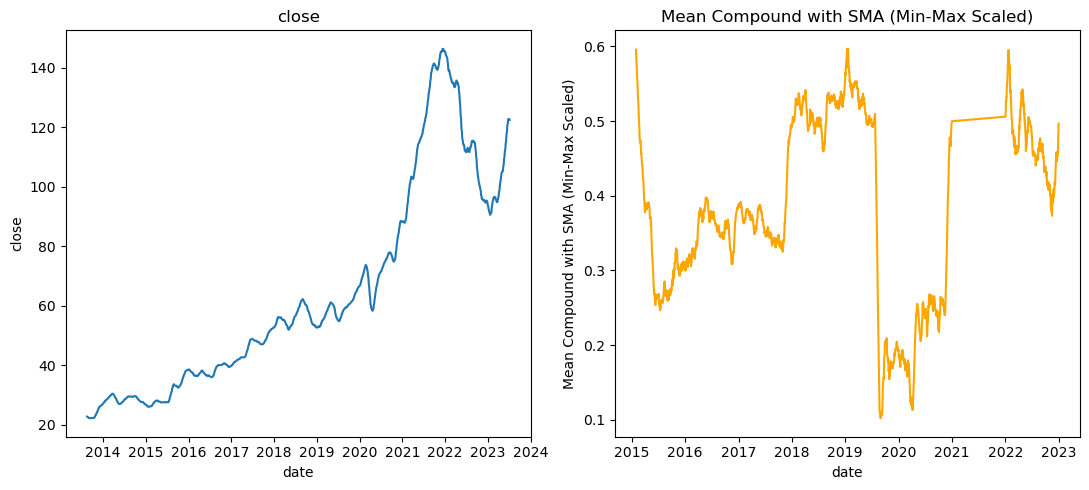

In [37]:
print_plots(
    google_df,
    average_sentiments_minmax_sma,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound with SMA (Min-Max Scaled)"
)

In [39]:
average_sentiments_std_sma = average_sentiments_df
average_sentiments_std_sma["compound_avg"] = sma(apply_standarization(average_sentiments_std_sma["compound_avg"]), 30)

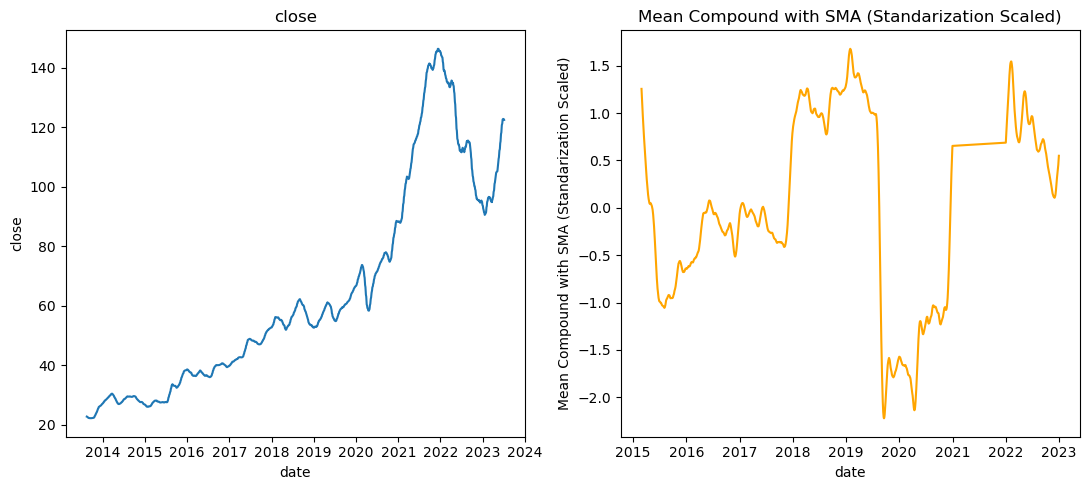

In [40]:
print_plots(
    google_df,
    average_sentiments_std_sma,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound with SMA (Standarization Scaled)"
)

In [41]:
all_sentiments = pd.DataFrame(data=transformed_tweet_list)

In [51]:
all_sentiments_min_max = all_sentiments
all_sentiments_min_max["compound"] = apply_min_max(all_sentiments_min_max["compound"])
all_sentiments_min_max_dict = all_sentiments_min_max.to_dict(orient='records')
all_sentiments_min_max_dict_average = list(merge_and_accumulate(all_sentiments_min_max_dict))
all_sentiments_min_max_dict_average_df = pd.DataFrame(data=all_sentiments_min_max_dict_average)

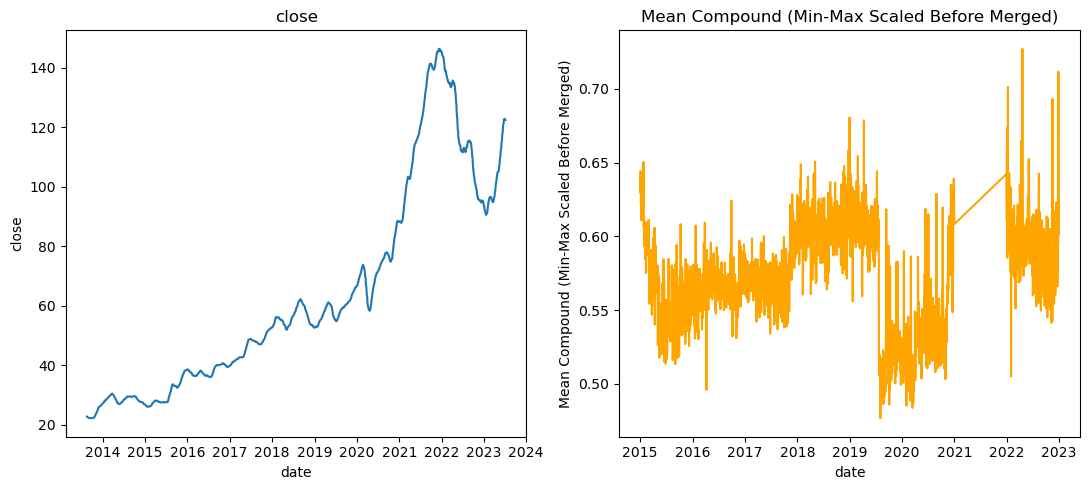

In [52]:
print_plots(
    google_df,
    all_sentiments_min_max_dict_average_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Min-Max Scaled Before Merged)"
)

In [53]:
all_sentiments_std = all_sentiments
all_sentiments_std["compound"] = apply_standarization(all_sentiments_std["compound"])
all_sentiments_std_dict = all_sentiments_std.to_dict(orient='records')
all_sentiments_std_dict_average = list(merge_and_accumulate(all_sentiments_std_dict))
all_sentiments_std_dict_average_df = pd.DataFrame(data=all_sentiments_std_dict_average)

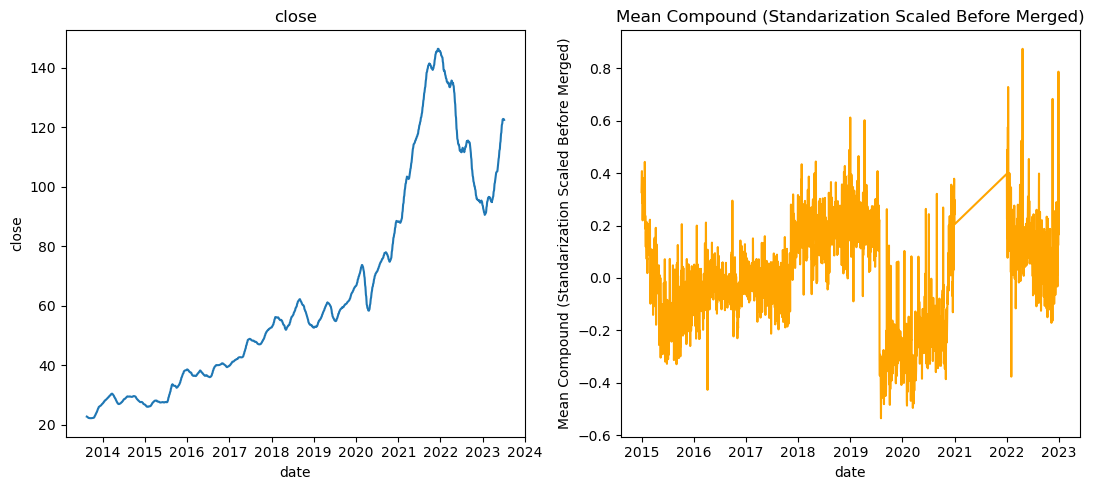

In [54]:
print_plots(
    google_df,
    all_sentiments_std_dict_average_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound (Standarization Scaled Before Merged)"
)

In [57]:
all_sentiments_min_max_dict_average

[{'date': '2015-01-01',
  'pos_avg': 0.1900406504065043,
  'neg_avg': 0.06122154471544718,
  'neu_avg': 0.748729674796747,
  'compound_avg': 0.6299231084016338},
 {'date': '2015-01-02',
  'pos_avg': 0.19865461847389568,
  'neg_avg': 0.058134538152610465,
  'neu_avg': 0.7431907630522089,
  'compound_avg': 0.6381090495260376},
 {'date': '2015-01-03',
  'pos_avg': 0.19975255623721888,
  'neg_avg': 0.06123517382413092,
  'neu_avg': 0.7389836400817993,
  'compound_avg': 0.6400115897941892},
 {'date': '2015-01-04',
  'pos_avg': 0.20483232323232334,
  'neg_avg': 0.058583838383838405,
  'neu_avg': 0.7365515151515153,
  'compound_avg': 0.6441962669023646},
 {'date': '2015-01-05',
  'pos_avg': 0.17968902439024398,
  'neg_avg': 0.051097560975609774,
  'neu_avg': 0.7691991869918694,
  'compound_avg': 0.6281988419944975},
 {'date': '2015-01-06',
  'pos_avg': 0.17739227642276445,
  'neg_avg': 0.05060975609756099,
  'neu_avg': 0.7719837398373985,
  'compound_avg': 0.6227358003527379},
 {'date': '2015

In [58]:
all_sentiments_min_max_dict_average_sma_df = pd.DataFrame(all_sentiments_min_max_dict_average)
all_sentiments_min_max_dict_average_sma_df["compound_avg"] = sma(all_sentiments_min_max_dict_average_sma_df["compound_avg"], 30)

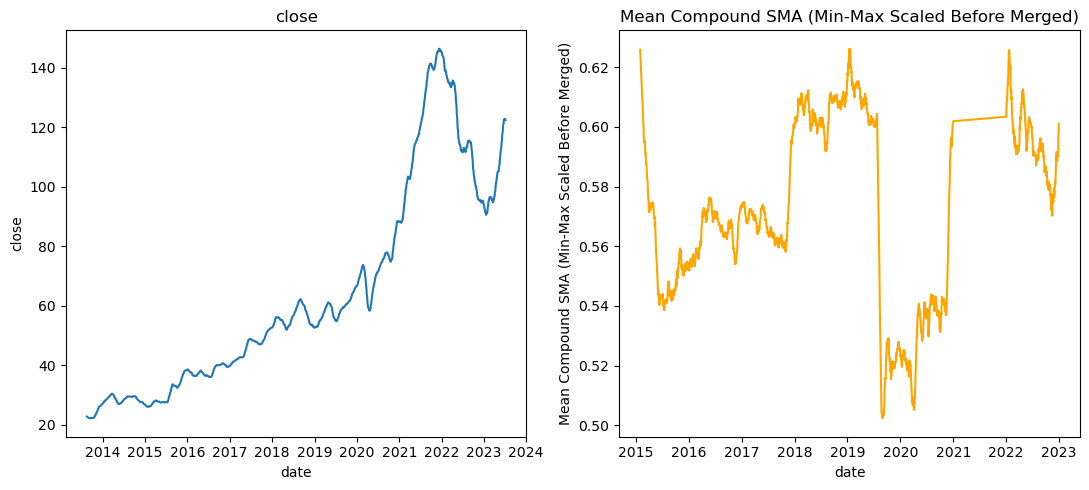

In [59]:
print_plots(
    google_df,
    all_sentiments_min_max_dict_average_sma_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound SMA (Min-Max Scaled Before Merged)"
)

In [60]:
all_sentiments_std_dict_average_sma_df = pd.DataFrame(all_sentiments_std_dict_average)
all_sentiments_std_dict_average_sma_df["compound_avg"] = sma(all_sentiments_std_dict_average_sma_df["compound_avg"], 30)

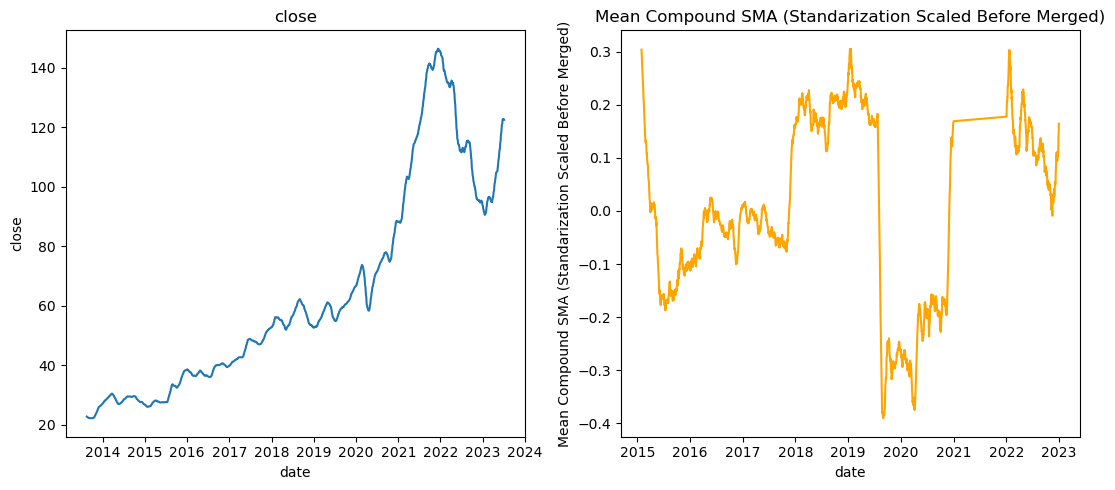

In [61]:
print_plots(
    google_df,
    all_sentiments_std_dict_average_sma_df,
    'close',
    'compound_avg',
    custom_b_name="Mean Compound SMA (Standarization Scaled Before Merged)"
)

In [ ]:
#Compare Scale Before And After Merge

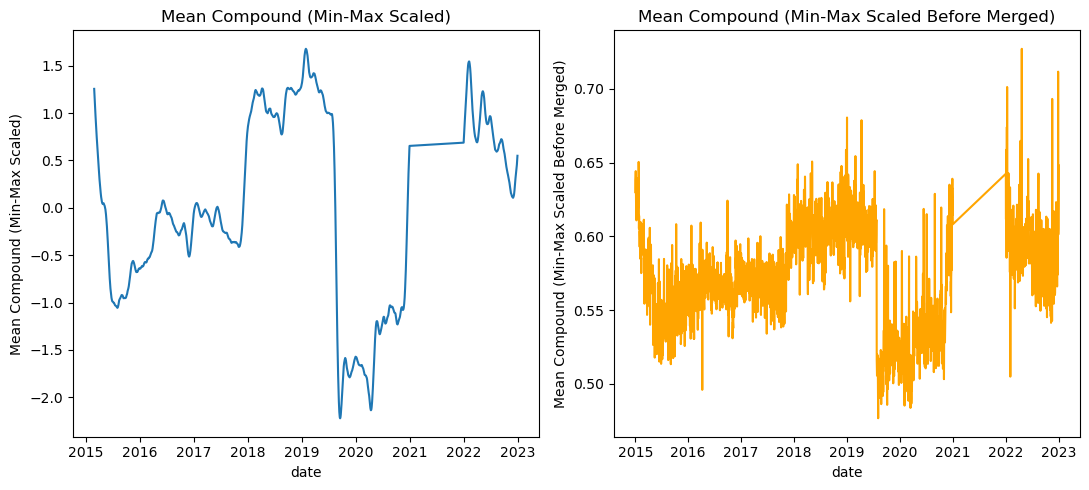

In [63]:
print_plots(
    average_sentiments_min_max,
    all_sentiments_min_max_dict_average_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound (Min-Max Scaled)",
    custom_b_name="Mean Compound (Min-Max Scaled Before Merged)"
)

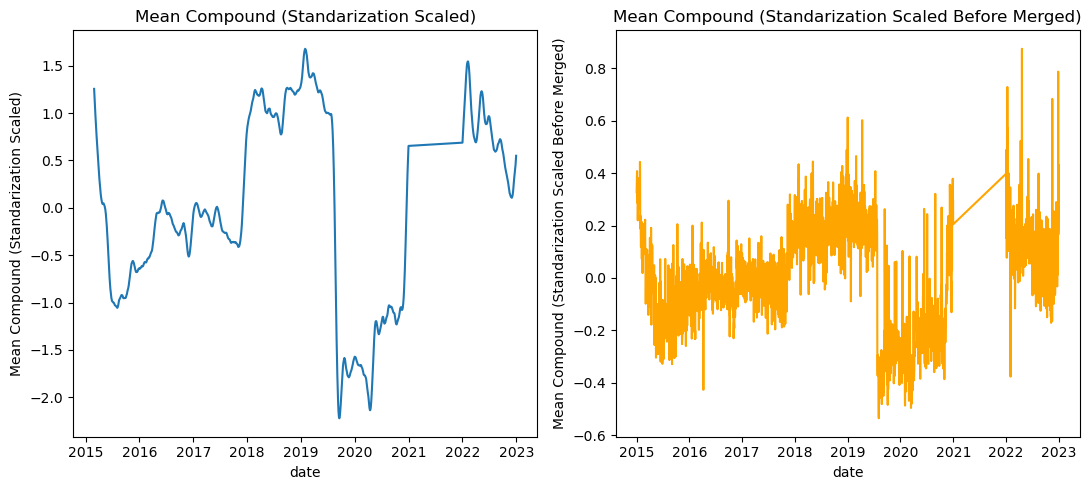

In [64]:
print_plots(
    average_sentiments_std,
    all_sentiments_std_dict_average_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound (Standarization Scaled)",
    custom_b_name="Mean Compound (Standarization Scaled Before Merged)"
)

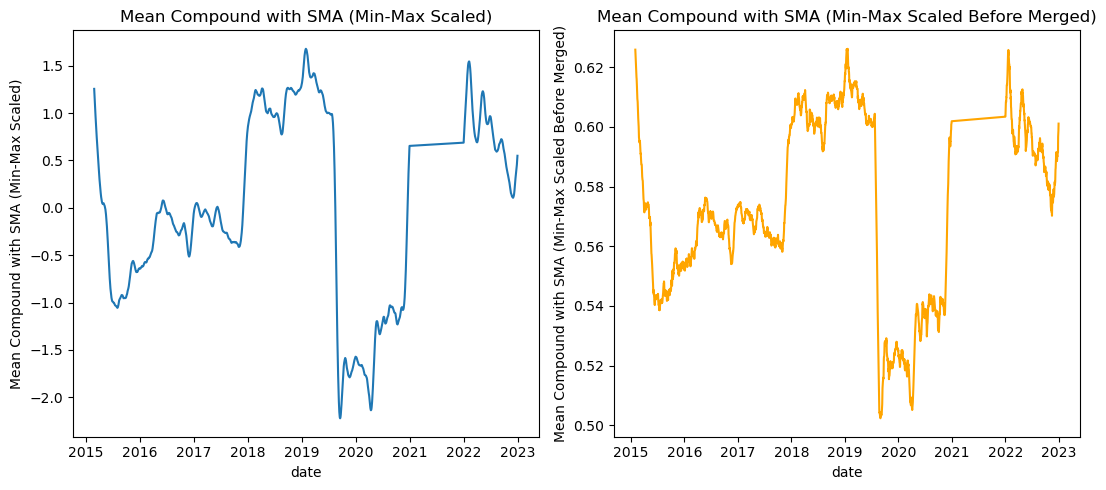

In [65]:
print_plots(
    average_sentiments_minmax_sma,
    all_sentiments_min_max_dict_average_sma_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound with SMA (Min-Max Scaled)",
    custom_b_name="Mean Compound with SMA (Min-Max Scaled Before Merged)"
)

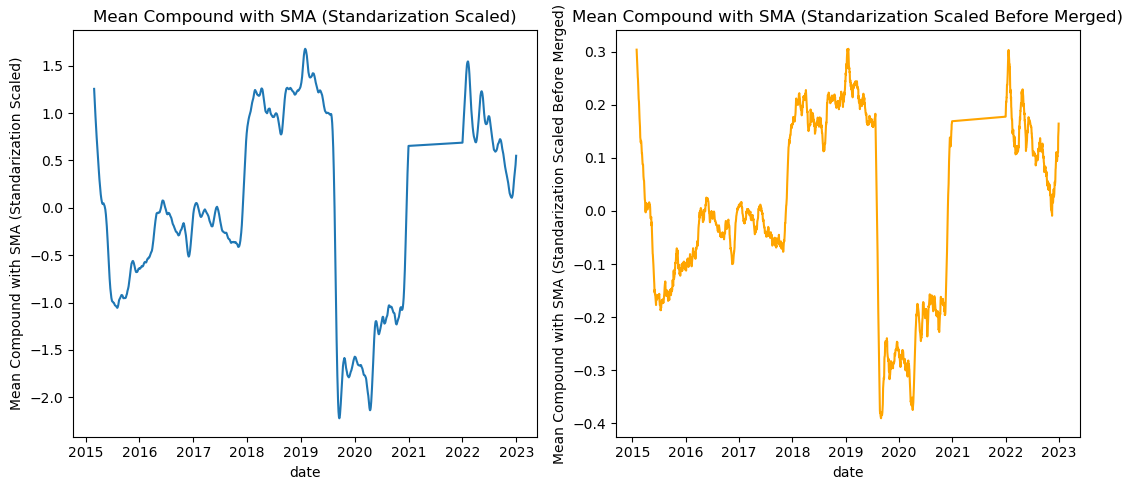

In [66]:
print_plots(
    average_sentiments_std_sma,
    all_sentiments_std_dict_average_sma_df,
    'compound_avg',
    'compound_avg',
    custom_a_name="Mean Compound with SMA (Standarization Scaled)",
    custom_b_name="Mean Compound with SMA (Standarization Scaled Before Merged)"
)